# Stellar Physical Characteristics — Analysis Notebook

## Introduction

As beautiful as the night sky is, a star can only ever be a single dot of light to our eyes. But they vary immensely in their size, age, brightness, color, and in many other ways. This project explores that variety and the way stars change as they age through data found in two catalogs of stellar observations.

What you can in the night sky tells you almost nothing about what's actually out there.

**Data Sources**

| Catalog | CDS ID | Records | Description |
|---------|--------|---------|-------------|
| Hipparcos | I/239/hip_main | ~118,000 | ESA astrometry satellite (1989–1993); precise parallaxes for stars across the whole sky |
| Woolley | V/32A/catalog | ~2,150 | Stars within 25 parsecs; the most complete census of our immediate stellar neighbourhood |

Both catalogs are accessed via the Strasbourg Astronomical Data Center TAP service (https://cds.unistra.fr/).

**Measured quantities**
- `b_v` — B-V colour index. The difference in brightness between blue and visual filters. Redder stars have higher B-V; bluer stars lower. It's a direct proxy for surface temperature.
- `plx` — trigonometric parallax in milliarcseconds. As Earth orbits the Sun, nearby stars appear to shift slightly against the background. The size of that shift gives distance: `dist_pc = 1000 / plx`
- `vmag` / `mv` — apparent and absolute visual magnitude. Apparent is how bright it looks from Earth; absolute is how bright it would look at a standard distance of 10 pc. Lower = brighter (don't ask me why).

**Stellar classification**

Stars are classified along two axes:

*Spectral class* (O B A F G K M, hottest to coolest) is determined by the star's surface temperature, which also governs its colour — O and B stars burn blue-white, K and M stars glow orange and red. Each class is further subdivided 0–9 (0 = hottest within that class).

*Luminosity class* (I–VII) captures how physically large and bright the star is relative to its temperature:
- **Ia / Ib** — Hypergiants / Supergiants
- **II** — Bright Giants
- **III** — Giants
- **IV** — Subgiants
- **V** — Main Sequence (most stars fall in this category, including the Sun)
- **VI** — Subdwarfs
- **VII** — White Dwarfs

Combined the create a two-letter descriptor (sometimes it's more complicated but we're going gloss over that for this analysis). The Sun is a moderately hot, middle-aged main sequence star classified **G2V**.. Polaris (the North Star) is **F7Ib**. It is a yellow supergiant about 50 times the Sun's diameter. Betelgeuse in Orion is **M1Ia**, a red supergiant so huge that if replaced the sun it would engulf the orbit of Jupiter.

---

**Questions explored below**

1. (SQL) Does Hipparcos exhibit luminosity bias compared to Woolley?
2. (SQL) How does the luminosity class mix shift with distance?
3. (SQL) What are the characteristic colour and brightness of each spectral × luminosity class combination?
4. (Python) How does absolute magnitude distribute within each luminosity class?
5. (Python) Hertzsprung-Russell diagrams for full dataset and by luminosity class


## Setup

In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import colorsys
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

DB = "stellar_analysis.db"

def query(sql: str, db: str = DB) -> pd.DataFrame:
    """Execute a SQL query and return results as a DataFrame."""
    with sqlite3.connect(db) as con:
        return pd.read_sql(sql, con)


> **Run ETL first** if the database doesn't exist yet:
> ```
> python etl.py --db stellar_analysis.db
> ```


In [ ]:
# Confirm tables are present
tables = query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")
print("Tables:", tables["name"].tolist())

counts = {
    t: query(f"SELECT COUNT(*) AS n FROM {t}").iloc[0]["n"]
    for t in tables["name"]
}
for t, n in counts.items():
    print(f"  {t}: {n:,} rows")


## Q1 — Does Hipparcos have a luminosity bias? (SQL)

Hipparcos observed the whole sky, but it's *flux-limited*: a star only makes it into the catalog if it's bright enough for the satellite's detectors to pick up. Since brightness falls off exponentially with distance, this creates a subtle but significant selection effect. If you look far enough away into the distance the only stars you can still see are the brightest ones.

The Woolley dataset sidesteps this entirely by being *distance-limited* instead. Every star within 25 parsecs gets in regardless of brightness, so it captures the faint red M dwarfs that Hipparcos misses. However because it's more representative of actual stellar populations as a whole, it contains no examples of the brightest and rarest types of stars.  

If the bias is real, we'd expect Hipparcos to be dominated by giants and supergiants while Woolley skews heavily toward main sequence stars. Let's check.


In [6]:
SQL_Q1 = """
WITH totals AS (
    SELECT src, COUNT(*) AS total
    FROM stars
    GROUP BY src
),
counts AS (
    SELECT
        src,
        lum_class,
        COUNT(CASE WHEN sp_class = 'O' THEN 1 END) AS O,
        COUNT(CASE WHEN sp_class = 'B' THEN 1 END) AS B,
        COUNT(CASE WHEN sp_class = 'A' THEN 1 END) AS A,
        COUNT(CASE WHEN sp_class = 'F' THEN 1 END) AS F,
        COUNT(CASE WHEN sp_class = 'G' THEN 1 END) AS G,
        COUNT(CASE WHEN sp_class = 'K' THEN 1 END) AS K,
        COUNT(CASE WHEN sp_class = 'M' THEN 1 END) AS M
    FROM stars
    GROUP BY src, lum_class
)
SELECT
    c.src,
    c.lum_class,
    ROUND(100.0 * c.O / t.total, 2) AS O_pct,
    ROUND(100.0 * c.B / t.total, 2) AS B_pct,
    ROUND(100.0 * c.A / t.total, 2) AS A_pct,
    ROUND(100.0 * c.F / t.total, 2) AS F_pct,
    ROUND(100.0 * c.G / t.total, 2) AS G_pct,
    ROUND(100.0 * c.K / t.total, 2) AS K_pct,
    ROUND(100.0 * c.M / t.total, 2) AS M_pct
FROM counts c
JOIN totals t ON c.src = t.src
WHERE lum_class NOT IN ('VI', 'VII', '')
ORDER BY
    c.src,
    CASE c.lum_class
        WHEN 'I'   THEN 1
        WHEN 'II'  THEN 2
        WHEN 'III' THEN 3
        WHEN 'IV'  THEN 4
        WHEN 'V'   THEN 5
        ELSE 6
    END
"""

df_q1 = query(SQL_Q1)
print(df_q1.to_string(index=False))


      src lum_class  O_pct  B_pct  A_pct  F_pct  G_pct  K_pct  M_pct
hipparcos         I   0.06   0.64   0.15   0.25   0.27   0.16   0.10
hipparcos        II   0.01   0.85   0.23   0.33   0.60   0.81   0.14
hipparcos       III   0.02   2.40   1.41   1.17   7.31  23.20   3.44
hipparcos        IV   0.01   2.04   2.44   3.56   2.55   0.95   0.01
hipparcos         V   0.09   6.15   8.10  16.87  10.23   2.95   0.40
  woolley        II   0.00   0.00   0.00   0.00   0.08   0.08   0.08
  woolley       III   0.00   0.00   0.41   0.66   0.74   2.64   0.33
  woolley        IV   0.00   0.00   0.33   3.22   3.05   0.99   0.00
  woolley         V   0.00   0.33   3.54  11.54  20.12  26.79  21.19


The difference is immediately obvious. In Hipparcos, Giants (III) alone account for over 30% of records; in Woolley, Main Sequence (V) stars make up well over 80%, with K and M dwarfs dominating. 

This is known as the Malmquist bias and is common type of systematic error in astronomy. If you try to estimate the average luminosity of stars from a magnitude-limited survey, you'll get a wildly inflated answer because you've excluded all the dim ones. The Woolley catalog exists precisely to correct for this in the solar neighbourhood.


## Q2 — How does the class mix shift with distance? (SQL)

In Q1 we demonstrated that the two datasets see two very different cross-sections of stellar populations. Now we must ask how quickly the combined dataset becomes unrepresentative as we look further out. We'd expect main sequence stars to dominate at short distances (where Woolley's coverage is strongest), and the giant/supergiant fraction to climb as we go further and only the bright objects remain visible.

In [ ]:
SQL_Q2 = """
WITH totals AS (
    SELECT
        (CAST(dist_pc / 50 AS INT) * 50) AS dist_bucket,
        COUNT(*) AS total
    FROM stars
    WHERE dist_pc IS NOT NULL
    GROUP BY dist_bucket
),
counts AS (
    SELECT
        (CAST(dist_pc / 50 AS INT) * 50) AS dist_bucket,
        COUNT(CASE WHEN lum_class = 'I'   THEN 1 END) AS I,
        COUNT(CASE WHEN lum_class = 'II'  THEN 1 END) AS II,
        COUNT(CASE WHEN lum_class = 'III' THEN 1 END) AS III,
        COUNT(CASE WHEN lum_class = 'IV'  THEN 1 END) AS IV,
        COUNT(CASE WHEN lum_class = 'V'   THEN 1 END) AS V
    FROM stars
    WHERE dist_pc IS NOT NULL
    GROUP BY dist_bucket
)
SELECT
    c.dist_bucket           AS dist_pc_bin,
    t.total,
    ROUND(100.0 * c.I   / t.total, 1) AS I_pct,
    ROUND(100.0 * c.II  / t.total, 1) AS II_pct,
    ROUND(100.0 * c.III / t.total, 1) AS III_pct,
    ROUND(100.0 * c.IV  / t.total, 1) AS IV_pct,
    ROUND(100.0 * c.V   / t.total, 1) AS V_pct
FROM counts c
JOIN totals t ON c.dist_bucket = t.dist_bucket
WHERE c.dist_bucket <= 500
ORDER BY c.dist_bucket
"""

df_q2 = query(SQL_Q2)
print(df_q2.to_string(index=False))


The transition is remarkably clean. In the 0–50 pc bin (the Woolley zone), ~80% of stars are main sequence. By 200–250 pc giants outnumber main sequence stars. By 400+ pc, the sample is almost exclusively giants and supergiants. This isn't because space suddenly fills up with giants, but because those are the only objects we can still see at that range.

This has a practical implication for the HR diagrams in Q5: we apply distance limits per luminosity class to achieve reasonable numbers of records with minimal error. Giants get a generous limit (100 pc), main sequence stars a tight one (50 pc).


## Q3 — Characteristic colour and brightness by spectral × luminosity class (SQL)

Now we get to the core of things. Each combination of spectral class (temperature) and luminosity class (approximate size) occupies a distinct region of the Hertzsprung-Russell diagram. This query collapses that diagram into a table. The numbers should tell a coherent story: stars get redder (higher B-V) as you move from O to M, and within any spectral class, giants should be dramatically brighter than dwarfs.

In [7]:
SQL_Q3 = """
SELECT
    sp_class,
    lum_class,
    COUNT(*)                        AS n,
    ROUND(AVG(b_v), 3)             AS mean_bv,
    ROUND(AVG(abs_mag), 2)         AS mean_abs_mag,
    ROUND(MIN(abs_mag), 2)         AS brightest,
    ROUND(MAX(abs_mag), 2)         AS dimmest
FROM stars
WHERE lum_class IN ('I', 'II', 'III', 'IV', 'V')
  AND sp_class  IN ('O', 'B', 'A', 'F', 'G', 'K', 'M')
GROUP BY sp_class, lum_class
HAVING COUNT(*) >= 5
ORDER BY
    CASE sp_class
        WHEN 'O' THEN 1 WHEN 'B' THEN 2 WHEN 'A' THEN 3
        WHEN 'F' THEN 4 WHEN 'G' THEN 5 WHEN 'K' THEN 6 WHEN 'M' THEN 7
    END,
    CASE lum_class
        WHEN 'I' THEN 1 WHEN 'II' THEN 2 WHEN 'III' THEN 3
        WHEN 'IV' THEN 4 WHEN 'V' THEN 5
    END
"""

df_q3 = query(SQL_Q3)
print(df_q3.to_string(index=False))


sp_class lum_class     n  mean_bv  mean_abs_mag  brightest  dimmest
       O         I    33    0.337         -2.84     -13.06     2.69
       O        II     6    0.116         -3.78      -5.40    -1.30
       O       III    13    0.174         -2.34      -5.30     0.95
       O        IV     6    0.324         -3.81     -11.72    -1.02
       O         V    49    0.176         -2.16     -10.42     5.35
       B         I   347    0.293         -2.56     -11.39     4.79
       B        II   461    0.046         -1.23     -12.34     3.65
       B       III  1300    0.013         -1.13     -11.18     5.52
       B        IV  1106   -0.010         -0.78     -10.54     3.93
       B         V  3334   -0.005         -0.32     -12.74     6.00
       A         I    82    0.435         -3.49     -10.09     3.73
       A        II   127    0.301          0.22     -10.37     4.25
       A       III   768    0.222          1.05      -7.57     4.53
       A        IV  1326    0.192          1.11 

The pattern holds exactly as stellar physics predicts. Reading down the chart, `mean_bv` climbs steadily. O stars are blue, M stars are deep red. Within the spectral class column, absolute magnitude changes significantly from class V to class I. A G-type supergiant is roughly 10,000× more luminous than a G-type main sequence star like our Sun.

The `n` column is also worth noting: K III giants dominate the Hipparcos sample (a known artifact of the selection bias from Q1), while M V dwarfs are underrepresented despite being the most common star type in the galaxy. Note that data quality is diminished for class I and class O stars due to their rarity and thus smaller sample size.


## Q4 — Absolute magnitude distributions by luminosity class (Python)

Tables summarise; histograms show shape. Within a luminosity class, how spread out are the brightnesses? A tight peak means physically uniform stars. A wide distribution means the class is much more varied.


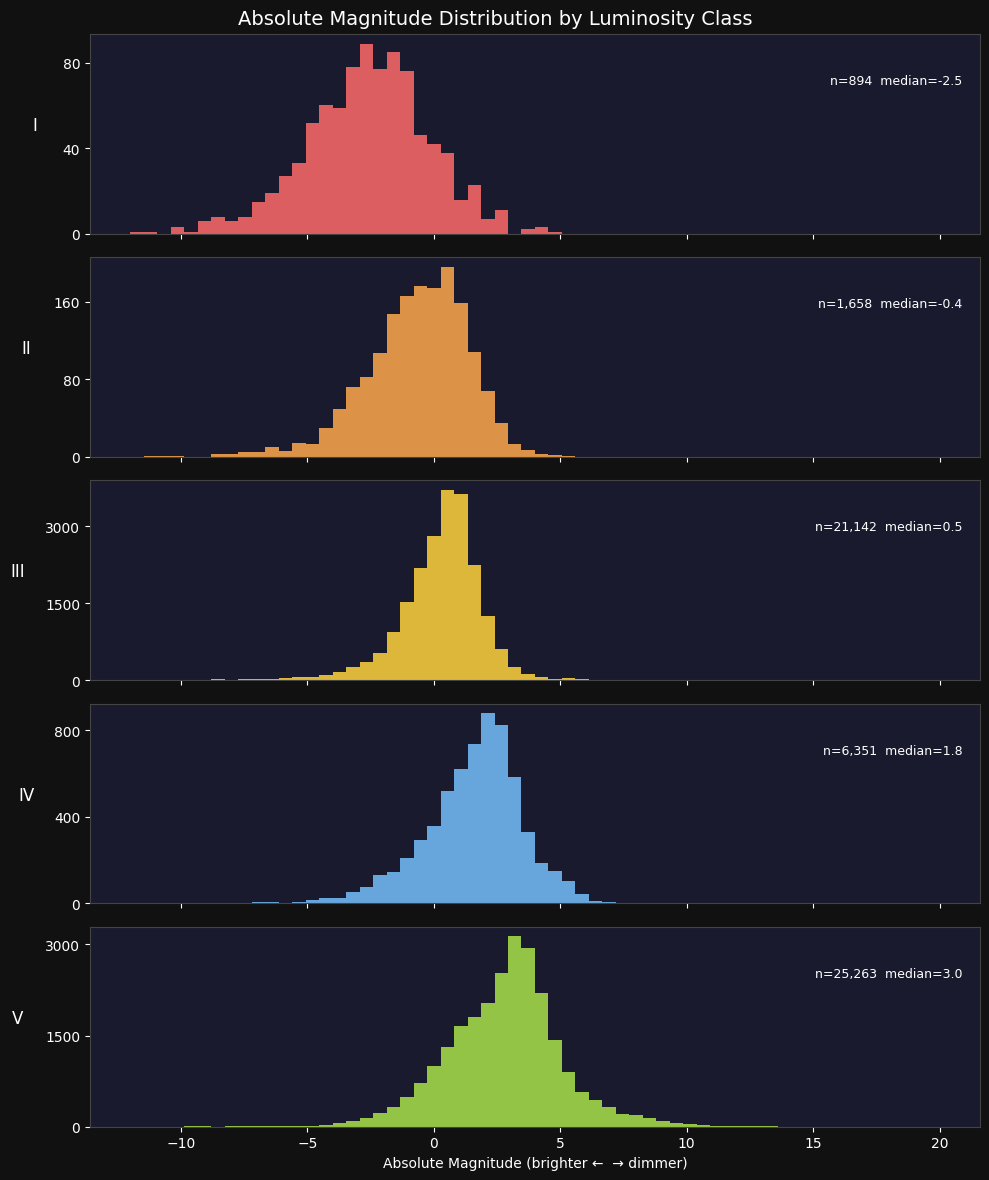

In [8]:
LUM_ORDER = ["I", "II", "III", "IV", "V"]
LUM_COLORS = {
    "I":   "#ff6b6b",   # Supergiants — red
    "II":  "#ffa94d",   # Bright Giants — orange
    "III": "#ffd43b",   # Giants — yellow
    "IV":  "#74c0fc",   # Subgiants — light blue
    "V":   "#a9e34b",   # Main Sequence — green
}

df_stars = query(
    "SELECT abs_mag, lum_class FROM stars WHERE lum_class IN ('I','II','III','IV','V')"
)

fig, axes = plt.subplots(
    len(LUM_ORDER), 1, figsize=(10, 12), sharex=True, facecolor="#111"
)
fig.patch.set_facecolor("#111")
fig.suptitle("Absolute Magnitude Distribution by Luminosity Class", color="white", fontsize=14)

for ax, lc in zip(axes, LUM_ORDER):
    sub = df_stars[df_stars["lum_class"] == lc]["abs_mag"].dropna()
    ax.hist(sub, bins=60, range=(-12, 20), color=LUM_COLORS[lc], alpha=0.85)
    ax.set_facecolor("#1a1a2e")
    ax.set_ylabel(lc, color="white", rotation=0, labelpad=20, fontsize=12)
    ax.tick_params(colors="white")
    ax.yaxis.set_major_locator(MaxNLocator(3))
    for spine in ax.spines.values():
        spine.set_edgecolor("#444")
    ax.text(
        0.98, 0.75, f"n={len(sub):,}  median={sub.median():.1f}",
        transform=ax.transAxes, ha="right", color="white", fontsize=9
    )

axes[-1].set_xlabel("Absolute Magnitude (brighter ←  → dimmer)", color="white")
plt.tight_layout()
plt.savefig("magnitude_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


A few things stand out:

- **Main sequence (V)** has the widest spread by far spanning nearly 15 magnitudes from hot B dwarfs to cool M dwarfs. This makes sense: "main sequence" just means hydrogen-burning, and that covers an enormous range of stellar masses and temperatures.
- **Giants (III)** are fairly broad but centered around Mv ≈ 0 to –2. They're evolved stars that have left the main sequence, but the spread reflects different masses of progenitor stars.
- **Supergiants (I)** cluster at the bright end (Mv ≈ –5 to –8) with relatively few objects. These stars are extremely rare because they burn through fuel so fast they don't live long, and require incredibly hydrogen-dense initial conditions to even form in the first place. A massive supergiant might last only a few million years; the Sun has been burning for 4.6 billion.


## Q5 — Hertzsprung-Russell diagrams (Python)

The HR diagram is an incredibly important tool in stellar astronomy. Much like the simultaneous discovery of calculus, the HR diagram was constructed independently by both Ejnar Hertzsprung and Henry Norris Russell in the early 1900s. It showed that stars aren't randomly distributed in colour-brightness spacem, but instead cluster into distinct sequences that reflect their physical nature and evolutionary stage.

Each point here is a real star. Colour is derived from B-V via Ballesteros' formula (which converts B-V to an approximate temperature, then to RGB) so the point colours approximate what you'd actually see if you looked at each star.

We plot the full dataset first, then break it out by luminosity class with distance limits chosen to minimize selection bias for each class.


In [9]:
def bv_to_rgb(bv: float, saturation_boost: float = 1.5) -> tuple[float, float, float]:
    """
    Convert B-V colour index to an approximate RGB colour.

    Steps:
    1. Ballesteros' formula: B-V -> temperature (K)
       Source: https://en.wikipedia.org/wiki/Color_index
    2. Temperature -> RGB (Tanner Helland algorithm)
       Source: https://tannerhelland.com/2012/09/18/convert-temperature-rgb-algorithm-code.html
    3. Saturation boost via HSV roundtrip as a little bit of artistic license
    """
    bv = np.clip(bv, -0.4, 2.0)
    t = 4600 * (1 / (0.92 * bv + 1.7) + 1 / (0.92 * bv + 0.62))
    t = np.clip(t, 1000, 40000) / 100.0

    r = 255 if t <= 66 else 329.699 * ((t - 60) ** -0.133)
    g = 99.471 * np.log(t) - 161.120 if t <= 66 else 288.122 * ((t - 60) ** -0.0756)
    b = 0 if t <= 19 else (255 if t >= 66 else 138.518 * np.log(t - 10) - 305.0448)

    r, g, b = (np.clip(x, 0, 255) / 255 for x in (r, g, b))
    h, s, v = colorsys.rgb_to_hsv(r, g, b)
    return colorsys.hsv_to_rgb(h, min(1.0, s * saturation_boost), v)


In [10]:
# Distance limits per luminosity class keep each panel from becoming sparse or dominated by noise.
# Giants and supergiants are visible from much farther out than dwarfs.
CONFIGS = [
    ("All",  None,  None,  "All Stars (combined)"),
    ("I",    None,  1000,  "Supergiants (I)"),
    ("II",   None,  500,   "Bright Giants (II)"),
    ("III",  None,  100,   "Giants (III)"),
    ("IV",   None,  200,   "Subgiants (IV)"),
    ("V",    None,  50,    "Main Sequence (V)"),
]

datasets = []
for lc, min_d, max_d, label in CONFIGS:
    clauses = []
    if lc != "All":
        clauses.append(f"lum_class = '{lc}'")
    if min_d is not None:
        clauses.append(f"dist_pc >= {min_d}")
    if max_d is not None:
        clauses.append(f"dist_pc <= {max_d}")
    where = ("WHERE " + " AND ".join(clauses)) if clauses else ""
    df = query(f"SELECT b_v, abs_mag FROM stars {where}")
    datasets.append((df, label))
    print(f"{label}: {len(df):,} stars")


All Stars (combined): 55,357 stars
Supergiants (I): 566 stars
Bright Giants (II): 1,072 stars
Giants (III): 1,481 stars
Subgiants (IV): 3,567 stars
Main Sequence (V): 4,007 stars


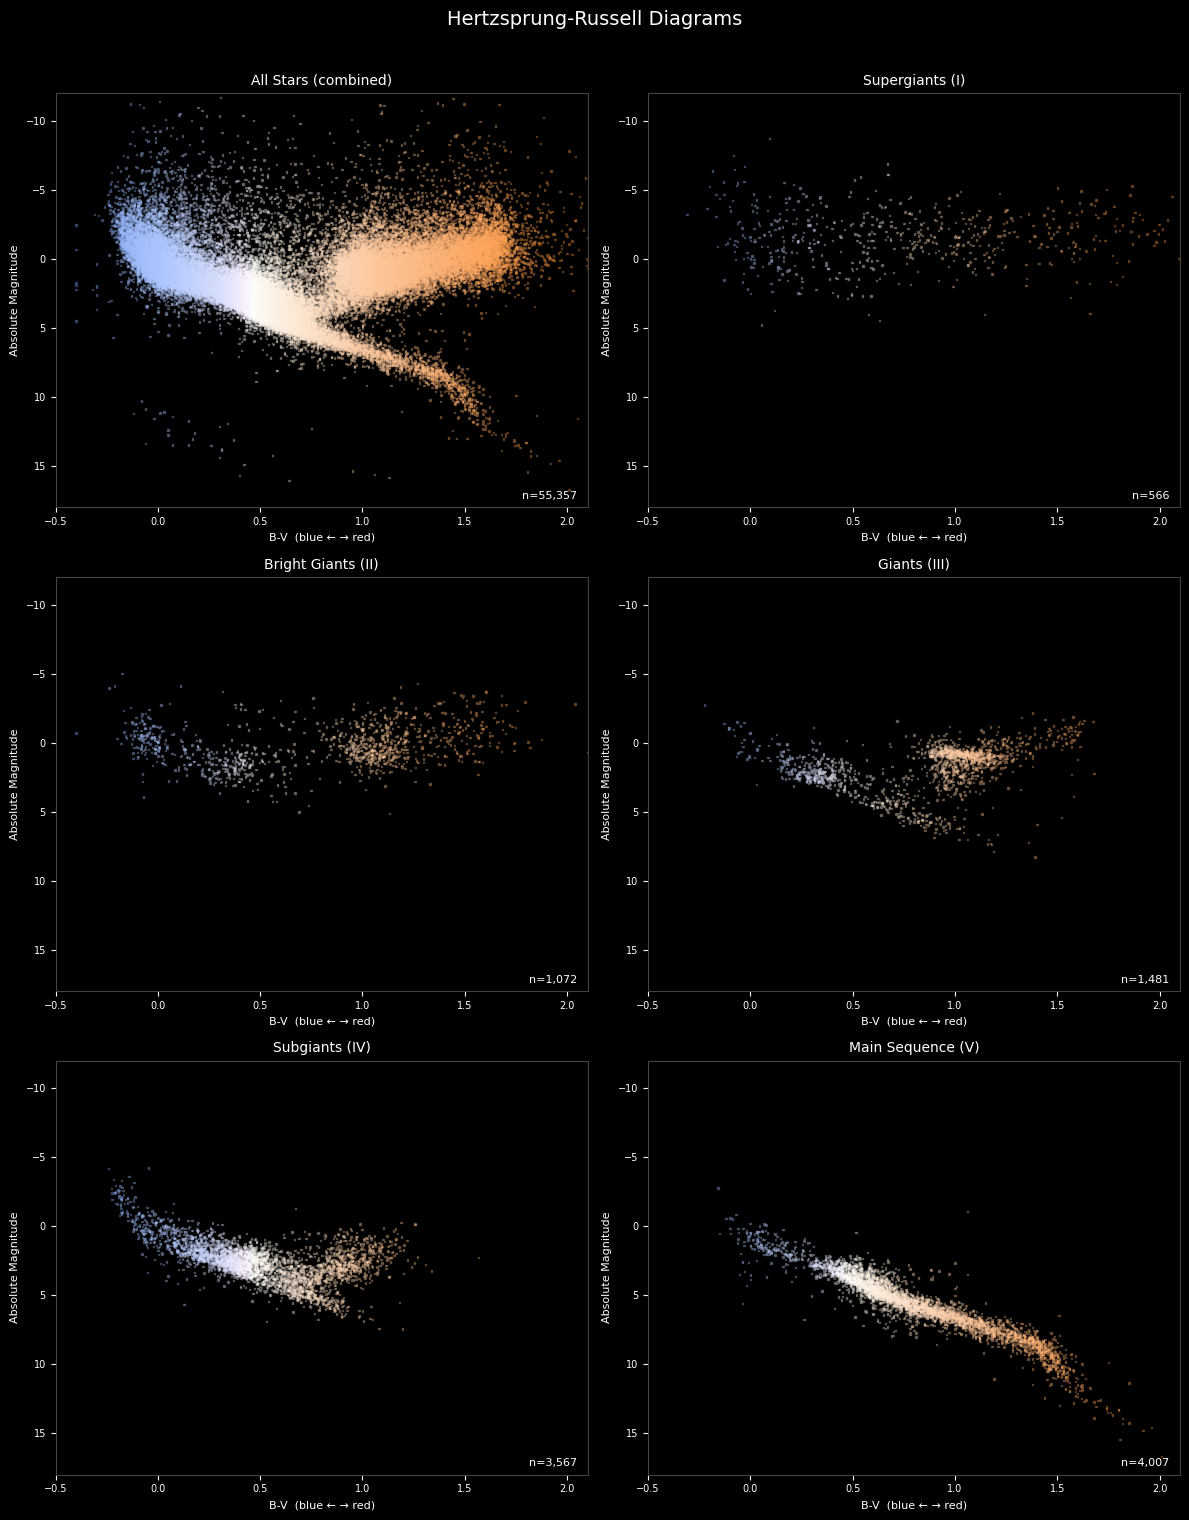

In [11]:
def plot_hr_panels(datasets, ncols: int = 2) -> None:
    """Render a grid of HR diagram panels, one per dataset."""
    nrows = -(-len(datasets) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 5), facecolor="black")
    fig.patch.set_facecolor("black")

    for ax, (df_sub, title) in zip(axes.flat, datasets):
        valid = df_sub.dropna(subset=["b_v", "abs_mag"])
        colors = valid["b_v"].apply(bv_to_rgb).tolist()
        ax.set_facecolor("black")
        ax.scatter(valid["b_v"], valid["abs_mag"],
                   c=colors, alpha=0.3, s=1, marker=",")
        ax.set_title(title, color="white", fontsize=10)
        ax.set_xlabel("B-V  (blue ← → red)", color="white", fontsize=8)
        ax.set_ylabel("Absolute Magnitude", color="white", fontsize=8)
        ax.tick_params(colors="white", labelsize=7)
        ax.set_xlim(-0.5, 2.1)
        ax.set_ylim(18, -12)
        ax.text(0.98, 0.02, f"n={len(valid):,}", transform=ax.transAxes,
                ha="right", color="white", fontsize=8)
        for spine in ax.spines.values():
            spine.set_edgecolor("#444")

    for ax in axes.flat[len(datasets):]:
        ax.set_visible(False)

    plt.suptitle("Hertzsprung-Russell Diagrams", color="white", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig("hr_diagrams.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_hr_panels(datasets, ncols=2)


A few things worth noticing:

- **All Stars** shows the full HR diagram structure: the main sequence runs diagonally from upper-left (hot and bright) to bottom-right (cool and dim), with a distinct giant branch arcing off to the upper-right. White dwarfs appear as a faint smear at the bottom-left.
- **Main Sequence (V)** at ≤50 pc is the cleanest panel with a tight diagonal sequence with colour shifting smoothly from blue-white (A/F stars, left) through yellow-white (G stars, Sun-like) to orange-red (K/M dwarfs, right). 
- **Giants (III)** form a much more horizontal band. They're all roughly the same absolute brightness but span a range of temperatures — they've expanded and cooled from their main sequence positions.
- **Supergiants (I)** are the scattered points at the top. They're rare, extreme, and cover the full colour range. There are blue supergiants (young and massive) and red supergiants (much older and cooler). Betelgeuse sits in that red supergiant cluster.

The power in this diagram is ability to show the the process of stellar evolution: the Sun will eventually exhaust its hydrogen core, expand until it envelops Venus (and possibly Earth!), and migrate off the main sequence into the giant branch. It's not massive enough to become a supergiant, but it will swell to roughly 100× its current radius before explosively shedding its outer layers at the end of it's life and leaving behind a white dwarf. That final end shows up in the white dwarf cluster at the bottom of the full diagram.
